In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Cargar el dataset procesado
df = pd.read_csv('dataset_listo_para_ml.csv')

# 2. Verificación de dimensión y tipos de datos
print("=== INFORMACIÓN DEL DATASET ===")
print(df.info())

print("\n=== VISTA PREVIA DE LOS DATOS ===")
display(df.head())

print("\n=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
display(df.describe().T)

print("\n=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===")
print(df['categoria'].value_counts())

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   consumo_kwh         1996 non-null   float64
 1   uso_horario_pico    1996 non-null   bool   
 2   cantidad_equipos    1996 non-null   int64  
 3   tipo_inmueble       1996 non-null   object 
 4   horas_alto_consumo  1996 non-null   int64  
 5   categoria           1996 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(2)
memory usage: 80.0+ KB
None

=== VISTA PREVIA DE LOS DATOS ===


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria
0,150.9,True,9,Apartamento,5,Moderado
1,399.3,False,21,Casa,9,Moderado
2,50.8,False,2,Comercial,1,Moderado
3,192.8,True,12,Apartamento,11,Ineficiente
4,270.2,True,20,Casa,6,Moderado



=== VALORES NULOS POR COLUMNA ===
consumo_kwh           0
uso_horario_pico      0
cantidad_equipos      0
tipo_inmueble         0
horas_alto_consumo    0
categoria             0
dtype: int64

=== ESTADÍSTICAS DESCRIPTIVAS ===


,count,mean,std,min,25%,50%,75%,max
consumo_kwh,1996.0,238.130611,151.857631,20.1,117.15,211.15,324.35,921.4
cantidad_equipos,1996.0,12.891784,6.620869,2.0,7.00,13.00,19.00,24.0
horas_alto_consumo,1996.0,6.012024,3.752474,0.0,3.00,6.00,9.00,12.0



=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===
categoria
Ineficiente    679
Eficiente      659
Moderado       658
Name: count, dtype: int64


/tmp/ipykernel_789/3374354335.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=df, x='categoria', palette='Set2', order=['Eficiente', 'Moderado', 'Ineficiente'])
/tmp/ipykernel_789/3374354335.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='tipo_inmueble', y='consumo_kwh', palette='Set3')
/tmp/ipykernel_789/3374354335.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 1], data=df, x='categoria', y='horas_alto_consumo', palette='Set2', order=['Eficiente', 'Moderado', 'Inefic

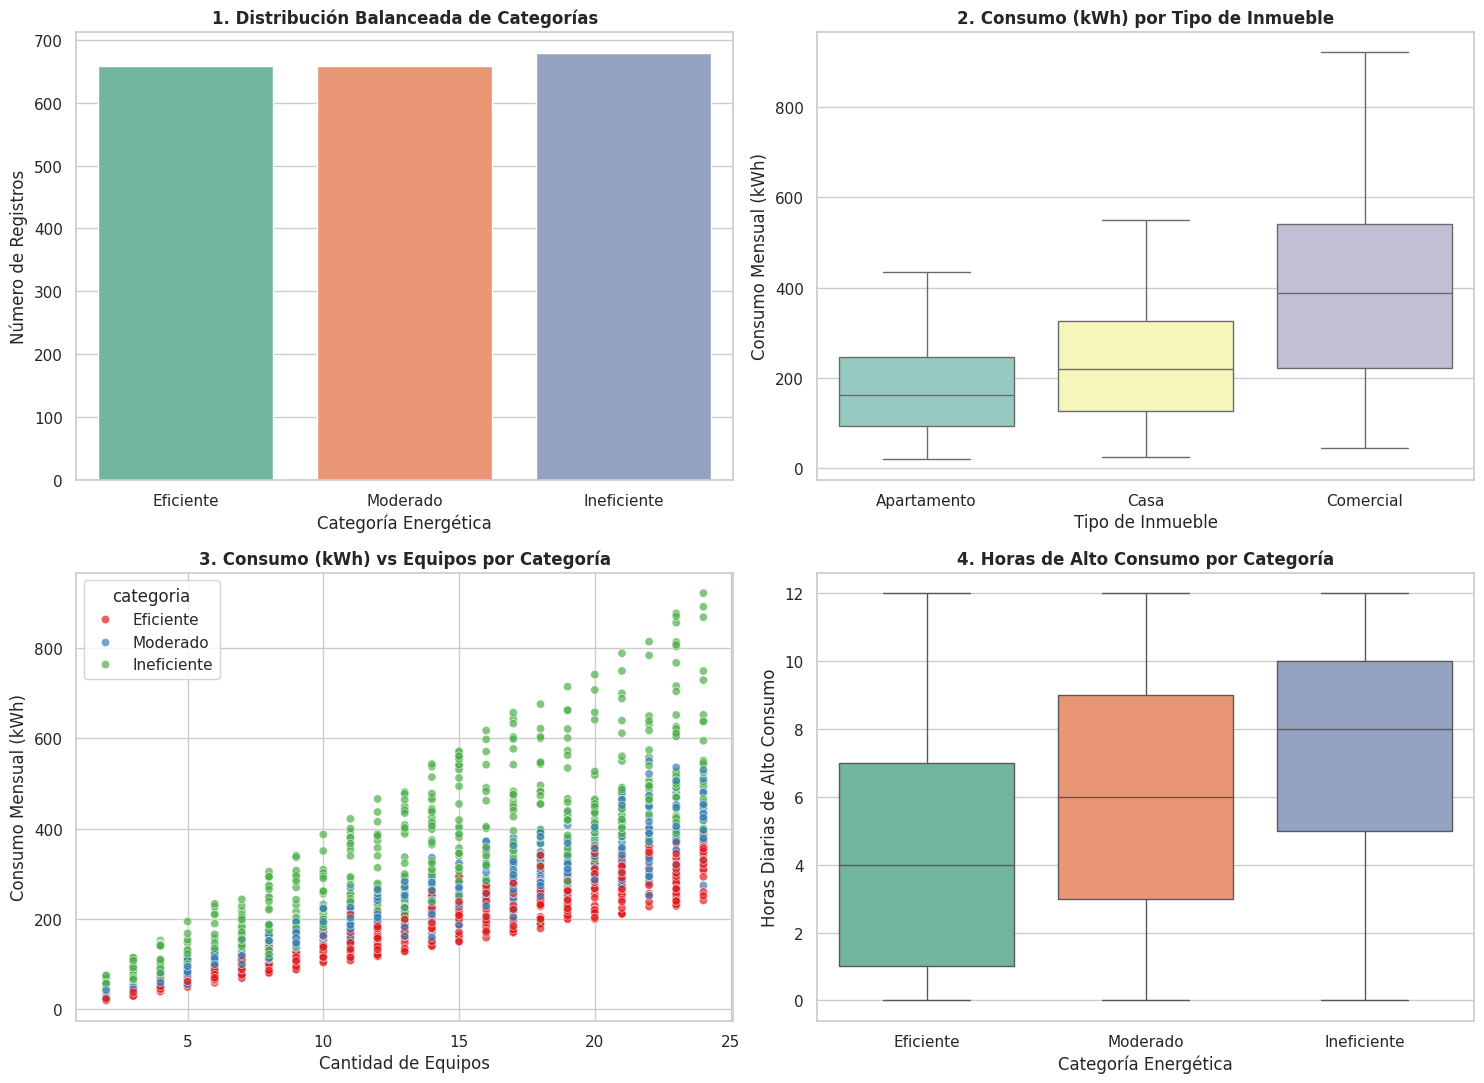

In [3]:
# Crear figura con 4 subgráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Gráfico 1: Balance de Clases
sns.countplot(ax=axes[0, 0], data=df, x='categoria', palette='Set2', order=['Eficiente', 'Moderado', 'Ineficiente'])
axes[0, 0].set_title('1. Distribución Balanceada de Categorías', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Categoría Energética')
axes[0, 0].set_ylabel('Número de Registros')

# Gráfico 2: Consumo kWh por Tipo de Inmueble
sns.boxplot(ax=axes[0, 1], data=df, x='tipo_inmueble', y='consumo_kwh', palette='Set3')
axes[0, 1].set_title('2. Consumo (kWh) por Tipo de Inmueble', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tipo de Inmueble')
axes[0, 1].set_ylabel('Consumo Mensual (kWh)')

# Gráfico 3: Consumo vs Equipos segmentado por Categoría
sns.scatterplot(
    ax=axes[1, 0], data=df, x='cantidad_equipos', y='consumo_kwh',
    hue='categoria', palette='Set1', alpha=0.7,
    hue_order=['Eficiente', 'Moderado', 'Ineficiente']
)
axes[1, 0].set_title('3. Consumo (kWh) vs Equipos por Categoría', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cantidad de Equipos')
axes[1, 0].set_ylabel('Consumo Mensual (kWh)')

# Gráfico 4: Horas de alto consumo según Categoría
sns.boxplot(ax=axes[1, 1], data=df, x='categoria', y='horas_alto_consumo', palette='Set2', order=['Eficiente', 'Moderado', 'Ineficiente'])
axes[1, 1].set_title('4. Horas de Alto Consumo por Categoría', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Categoría Energética')
axes[1, 1].set_ylabel('Horas Diarias de Alto Consumo')

plt.tight_layout()
plt.savefig('eda_energiai.png', dpi=300)
plt.show()

In [4]:
# ==========================================
# PASO 3: INGENIERÍA DE CARACTERÍSTICAS
# ==========================================

# 1. Crear la variable explicativa de intensidad
df['consumo_por_equipo'] = df['consumo_kwh'] / df['cantidad_equipos']

# 2. Verificar estadísticas de la nueva variable
print("=== ESTADÍSTICAS DE 'consumo_por_equipo' ===")
print(df['consumo_por_equipo'].describe())

# 3. Vista previa de las columnas involucradas
print("\n=== VISTA PREVIA ===")
display(df[['consumo_kwh', 'cantidad_equipos', 'consumo_por_equipo', 'categoria']].head())

=== ESTADÍSTICAS DE 'consumo_por_equipo' ===
count    1996.000000
mean       18.425875
std         6.288085
min         9.808333
25%        14.100000
50%        16.934848
75%        21.138571
max        38.966667
Name: consumo_por_equipo, dtype: float64

=== VISTA PREVIA ===


,consumo_kwh,cantidad_equipos,consumo_por_equipo,categoria
0,150.9,9,16.766667,Moderado
1,399.3,21,19.014286,Moderado
2,50.8,2,25.400000,Moderado
3,192.8,12,16.066667,Ineficiente
4,270.2,20,13.510000,Moderado


In [5]:
# ==========================================
# PASO 4: DIVISIÓN ESTRATIFICADA (TRAIN / TEST)
# ==========================================

from sklearn.model_selection import train_test_split

# 1. Separar características (X) y etiqueta objetivo (y)
X = df.drop(columns=['categoria'])
y = df['categoria']

# 2. Dividir en conjuntos de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Validar las dimensiones resultantes
print("=== DIMENSIONES DE LOS CONJUNTOS ===")
print(f"Conjunto de Entrenamiento (X_train): {X_train.shape[0]} filas, {X_train.shape[1]} columnas")
print(f"Conjunto de Prueba (X_test):        {X_test.shape[0]} filas, {X_test.shape[1]} columnas")

# 4. Verificar la estratificación de clases en ambos conjuntos
print("\n=== PROPORCIÓN DE CLASES EN TRAIN ===")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

print("\n=== PROPORCIÓN DE CLASES EN TEST ===")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

=== DIMENSIONES DE LOS CONJUNTOS ===
Conjunto de Entrenamiento (X_train): 1596 filas, 6 columnas
Conjunto de Prueba (X_test):        400 filas, 6 columnas

=== PROPORCIÓN DE CLASES EN TRAIN ===
categoria
Ineficiente    34.02 %
Eficiente      33.02 %
Moderado       32.96 %
Name: proportion, dtype: object

=== PROPORCIÓN DE CLASES EN TEST ===
categoria
Ineficiente    34.0 %
Eficiente      33.0 %
Moderado       33.0 %
Name: proportion, dtype: object


In [6]:
# ==========================================
# PASO 5: PIPELINE DE PREPROCESAMIENTO
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Agrupar columnas según su tipo
num_features = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 'consumo_por_equipo']
cat_features = ['tipo_inmueble', 'uso_horario_pico']

# 2. Configurar el preprocesador estructurado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ]
)

# 3. Probar la transformación en X_train para verificar
X_train_transformed = preprocessor.fit_transform(X_train)

# 4. Mostrar el resultado de la transformación
print("=== PREPROCESAMIENTO CONFIGURADO ===")
print(f"Dimensión original de X_train:    {X_train.shape}")
print(f"Dimensión transformada de X_train:{X_train_transformed.shape}")
print("\nCaracterísticas finales generadas para el modelo:")
for col in preprocessor.get_feature_names_out():
    print(f" - {col}")

=== PREPROCESAMIENTO CONFIGURADO ===
Dimensión original de X_train:    (1596, 6)
Dimensión transformada de X_train:(1596, 7)

Características finales generadas para el modelo:
 - num__consumo_kwh
 - num__cantidad_equipos
 - num__horas_alto_consumo
 - num__consumo_por_equipo
 - cat__tipo_inmueble_Casa
 - cat__tipo_inmueble_Comercial
 - cat__uso_horario_pico_True


In [7]:
# ==========================================
# PASO 6: ENTRENAMIENTO Y COMPARACIÓN DE MODELOS
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Definir los modelos a evaluar
models = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
pipelines_dict = {}

# 2. Entrenar y evaluar cada modelo dentro del Pipeline
for name, clf in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    # Entrenamiento
    pipe.fit(X_train, y_train)

    # Predicción en el conjunto de prueba
    y_pred = pipe.predict(X_test)

    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results.append({
        'Modelo': name,
        'Accuracy': f"{acc * 100:.2f}%",
        'F1-Score Macro': f"{f1_macro * 100:.2f}%"
    })

    # Guardar el pipeline entrenado para el modelo seleccionado
    pipelines_dict[name] = pipe

# 3. Presentar la tabla comparativa
df_results = pd.DataFrame(results)
print("=== TABLA COMPARATIVA DE MODELOS ===")
display(df_results)

=== TABLA COMPARATIVA DE MODELOS ===


,Modelo,Accuracy,F1-Score Macro
0,Regresión Logística,95.00%,95.02%
1,Árbol de Decisión,93.75%,93.66%
2,Random Forest,93.50%,93.41%


=== REPORTE DE CLASIFICACIÓN DETALLADO ===
              precision    recall  f1-score   support

   Eficiente     0.9398    0.9470    0.9434       132
 Ineficiente     0.9371    0.9853    0.9606       136
    Moderado     0.9274    0.8712    0.8984       132

    accuracy                         0.9350       400
   macro avg     0.9348    0.9345    0.9341       400
weighted avg     0.9348    0.9350    0.9344       400



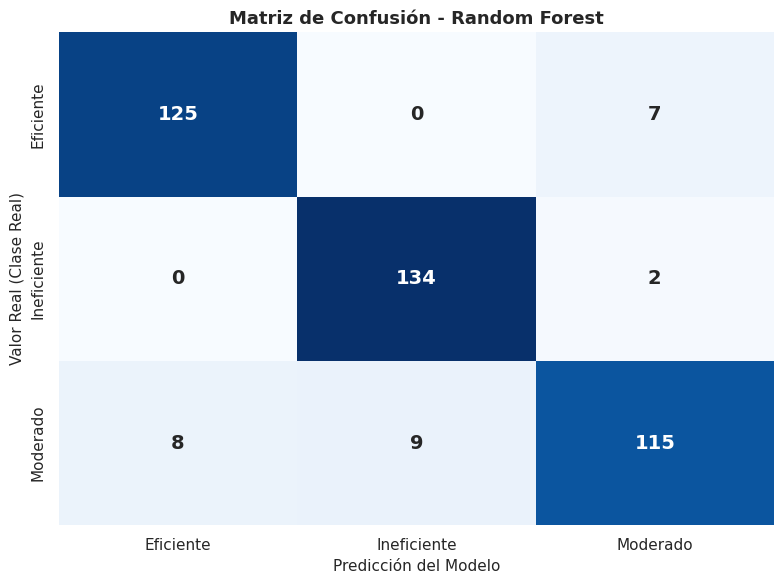

In [8]:
# ==========================================
# PASO 7: EVALUACIÓN DETALLADA (MÉTRICAS Y MATRIZ)
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar el pipeline entrenado de Random Forest
best_pipeline = pipelines_dict['Random Forest']

# 2. Generar predicciones sobre el conjunto de prueba
y_pred = best_pipeline.predict(X_test)

# 3. Mostrar el reporte de clasificación completo
print("=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test, y_pred, digits=4))

# 4. Generar y visualizar la Matriz de Confusión
classes = best_pipeline.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes,
    cbar=False, annot_kws={"size": 14, "weight": "bold"}
)
plt.title('Matriz de Confusión - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=11)
plt.ylabel('Valor Real (Clase Real)', fontsize=11)
plt.tight_layout()
plt.savefig('matriz_confusion_rf.png', dpi=300)
plt.show()

In [10]:
# ==========================================
# PASO 8: SERIALIZACIÓN Y PRUEBA DE INFERENCIA
# ==========================================

import joblib
import pandas as pd

# 1. Reentrenar el Pipeline final con el 100% del dataset
final_pipeline = pipelines_dict['Random Forest']
final_pipeline.fit(X, y)

# 2. Guardar el Pipeline completo en disco
model_filename = 'energiai_model.joblib'
joblib.dump(final_pipeline, model_filename)

print(f"=== MODELO EXPORTADO CON ÉXITO: {model_filename} ===")

# ------------------------------------------
# PRUEBA DE CARGA EN TIEMPO REAL (SIMULACIÓN API)
# ------------------------------------------

# 3. Cargar el modelo desde el archivo generado
loaded_model = joblib.load(model_filename)

# 4. JSON de entrada simulado (petición HTTP POST)
sample_payload = {
    'consumo_kwh': 420.0,
    'uso_horario_pico': True,
    'cantidad_equipos': 10,
    'tipo_inmueble': 'Casa',
    'horas_alto_consumo': 8
}

# 5. Transformar la entrada al formato esperado por el pipeline
df_sample = pd.DataFrame([sample_payload])
df_sample['consumo_por_equipo'] = df_sample['consumo_kwh'] / df_sample['cantidad_equipos']

# 6. Ejecutar predicción y probabilidad
categoria_predicha = loaded_model.predict(df_sample)[0]
probabilidades = loaded_model.predict_proba(df_sample)[0]
probabilidad_max = max(probabilidades)

print("\n=== RESULTADO DE LA PRUEBA DE INFERENCIA ===")
print(f"Entrada recibida:    {sample_payload}")
print(f"Categoría asignada: {categoria_predicha}")
print(f"Certeza/Probabilidad: {probabilidad_max:.2f} ({probabilidad_max * 100:.1f}%)")

=== MODELO EXPORTADO CON ÉXITO: energiai_model.joblib ===

=== RESULTADO DE LA PRUEBA DE INFERENCIA ===
Entrada recibida:    {'consumo_kwh': 420.0, 'uso_horario_pico': True, 'cantidad_equipos': 10, 'tipo_inmueble': 'Casa', 'horas_alto_consumo': 8}
Categoría asignada: Ineficiente
Certeza/Probabilidad: 0.99 (99.0%)


In [11]:
import joblib
import pandas as pd

# 1. Cargar el modelo guardado
model = joblib.load('energiai_model.joblib')

# 2. Entrada simulada en bruto
test_data = pd.DataFrame([{
    'consumo_kwh': 110.0,
    'uso_horario_pico': False,
    'cantidad_equipos': 12,
    'tipo_inmueble': 'Apartamento',
    'horas_alto_consumo': 2
}])

# 3. Aplicar Feature Engineering
test_data['consumo_por_equipo'] = test_data['consumo_kwh'] / test_data['cantidad_equipos']

# 4. Inferencia
pred = model.predict(test_data)[0]
prob = max(model.predict_proba(test_data)[0])

print(f"Estado del Modelo: ¡LISTO PARA ENTREGA!")
print(f"Predicción de prueba: {pred} (Certeza: {prob:.2%})")

Estado del Modelo: ¡LISTO PARA ENTREGA!
Predicción de prueba: Eficiente (Certeza: 100.00%)
